# 07 — Memory traffic under concurrency (the HBM question)

**Objective.** Test the experimental motivation of the thesis: that raising concurrency raises the pressure on
the memory subsystem, and find which backend produces more memory traffic in the regime the thesis cares about.

**Research question.** Does more concurrency produce more memory traffic, how close does each backend get to the
sustainable bandwidth of the socket, and what makes up that traffic?

**Hypothesis under test.**
more concurrent requests → more aggregate token generation → more weight/KV memory activity → more memory
pressure → better conditions to study HBM/DDR behaviour. The measurements below test each link instead of
assuming it.

**Data.** `online_points`: memory read/write traffic of the server process tree from core PMU counters over each
steady window (validated against STREAM in notebook 01), the STREAM baseline measured with the same counters, and
the servers' step counters.

**Method.** Utilization = server traffic ÷ maximum STREAM traffic of the same layout measured with the same
counters. A first-principles model gives the minimum read traffic: forward steps/s × bytes streamed per step (all
weights except the gathered embedding table) + decode tokens/s × mean context × KV bytes per token
(`analysis.memory.add_traffic_model`).

**Limits.** In HBM cache mode the counters see HBM-cache hits and DDR traffic together; they cannot tell which
level served the traffic. Whether a point's active working set (streamed weights + live KV) fits in the 64 GiB
HBM cache is computed below; where it fits, the traffic is predominantly served by HBM, apart from conflict misses.

In [1]:
import pandas as pd
from IPython.display import display

from llm_backend_analysis.analysis import comparisons, memory, metrics
from llm_backend_analysis.data import loaders, registry
from llm_backend_analysis.reporting import Claim, claims_table, num, pct, rng, show, table, x
from llm_backend_analysis.visualization import plots, theme
from llm_backend_analysis.visualization.export import export_figure

theme.setup_notebook()
NOTEBOOK = "07_memory_traffic.ipynb"
MODEL = registry.primary_model()  # Llama-3.1-8B-Instruct; the 1B model is the cross-check

In [2]:
pts = memory.add_traffic_model(metrics.add_scaling_metrics(loaders.online_points()))
primary = pts[pts["model"] == MODEL]
ceiling = memory.stream_ceiling(pts)
big = pts[pts["working_set_gib_model"] > 64]
show(f"Sustainable traffic of the server layout (STREAM, same counters): **{num(ceiling)} GB/s**. Modelled active working "
     f"set: {rng(pts['working_set_gib_model'], num, nd=1)} GiB; {len(pts) - len(big)} of {len(pts)} points fit in the 64 GiB "
     "HBM cache. Points that exceed it: "
     + (", ".join(f"{r.configuration_label} {r.workload_shape} C={r.concurrency} ({r.working_set_gib_model:.0f} GiB)"
                  for r in big.itertuples()) or "none") + ".")

Sustainable traffic of the server layout (STREAM, same counters): **502 GB/s**. Modelled active working set: 1.2–79.0 GiB; 144 of 145 points fit in the 64 GiB HBM cache. Points that exceed it: vLLM · BF16 8192→256 C=64 (79 GiB).

## 1. Throughput and memory traffic together

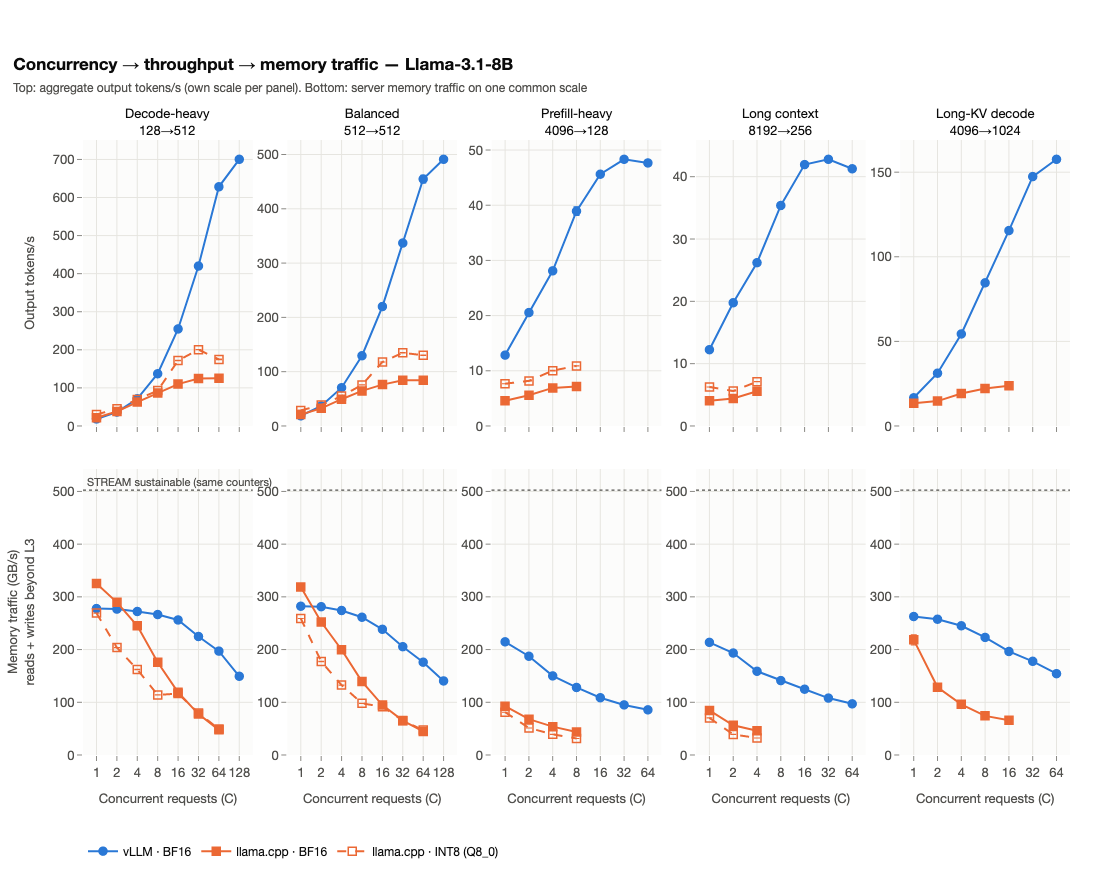

In [3]:
fig = plots.concurrency_grid(primary, [
    plots.Panel("output_tok_s_mean", "Output tokens/s", "tok/s"),
    plots.Panel("mem_total_gbs_mean", "Memory traffic (GB/s)<br>reads + writes beyond L3", "GB/s", share_y=True,
                fmt=".0f", reference=(ceiling, "STREAM sustainable (same counters)")),
], title=f"Concurrency → throughput → memory traffic — {registry.model_label(MODEL)}",
   subtitle="Top: aggregate output tokens/s (own scale per panel). Bottom: server memory traffic on one common scale")
fig.show()
export_figure(fig, "throughput_and_memory_traffic", source=NOTEBOOK,
              caption="Output tokens/s (top) and server memory traffic (bottom) vs concurrency, with the STREAM ceiling (8B).")

In [4]:
trend = memory.traffic_trend(pts)
trend = trend.assign(configuration=trend["configuration_id"].map(registry.configuration_label),
                     workload_s=trend["workload"].map(lambda w: registry.workload_label(w, short=True)),
                     model_l=trend["model"].map(registry.model_label))
display(table(trend[["model_l", "workload_s", "configuration", "mem_total_gbs_first", "mem_total_gbs_last", "c_last",
                     "bw_util_first", "bw_util_last", "c_at_max_traffic"]]
              .rename(columns={"model_l": "Model", "workload_s": "Workload", "configuration": "Configuration",
                               "mem_total_gbs_first": "GB/s at C=1", "mem_total_gbs_last": "GB/s at highest C",
                               "c_last": "highest C", "bw_util_first": "Share of STREAM at C=1",
                               "bw_util_last": "Share at highest C", "c_at_max_traffic": "C with most traffic"}),
              {"GB/s at C=1": "{:.0f}", "GB/s at highest C": "{:.0f}", "Share of STREAM at C=1": "{:.0%}",
               "Share at highest C": "{:.0%}"}))
show(f"Traffic is highest at C = 1 for {int((trend['c_at_max_traffic'] == 1).sum())} of {len(trend)} curves and lower at the "
     f"highest C than at C = 1 for {int(trend['traffic_falls_with_c'].sum())} of {len(trend)}. The largest share of "
     f"sustainable bandwidth anywhere is {pct(trend['max_bw_util'].max(), signed=False)} "
     f"({trend.loc[trend['max_bw_util'].idxmax(), 'configuration']}, {trend.loc[trend['max_bw_util'].idxmax(), 'workload_s']}).")

Model,Workload,Configuration,GB/s at C=1,GB/s at highest C,highest C,Share of STREAM at C=1,Share at highest C,C with most traffic
Llama-3.1-8B,128→512,vLLM · BF16,278,149,128,55%,30%,1
Llama-3.1-8B,128→512,llama.cpp · BF16,325,48,64,65%,9%,1
Llama-3.1-8B,128→512,llama.cpp · INT8 (Q8_0),269,49,64,54%,10%,1
Llama-3.1-8B,512→512,vLLM · BF16,282,140,128,56%,28%,1
Llama-3.1-8B,512→512,llama.cpp · BF16,319,45,64,63%,9%,1
Llama-3.1-8B,512→512,llama.cpp · INT8 (Q8_0),259,47,64,52%,9%,1
Llama-3.1-8B,4096→128,vLLM · BF16,215,86,64,43%,17%,1
Llama-3.1-8B,4096→128,llama.cpp · BF16,93,44,8,18%,9%,1
Llama-3.1-8B,4096→128,llama.cpp · INT8 (Q8_0),81,31,8,16%,6%,1
Llama-3.1-8B,8192→256,vLLM · BF16,214,97,64,43%,19%,1


Traffic is highest at C = 1 for 21 of 23 curves and lower at the highest C than at C = 1 for 23 of 23. The largest share of sustainable bandwidth anywhere is 65% (llama.cpp · BF16, 128→512).

**Interpretation.** The first link of the hypothesis holds for vLLM (more concurrency → much more throughput) but
the next one does not hold for either backend: **total memory traffic is highest with one request and falls as
concurrency rises**, and no configuration approaches the sustainable bandwidth. Concurrency moves serving towards
compute-bound operation, not towards HBM saturation. Section 2 explains why.

## 2. What the traffic consists of

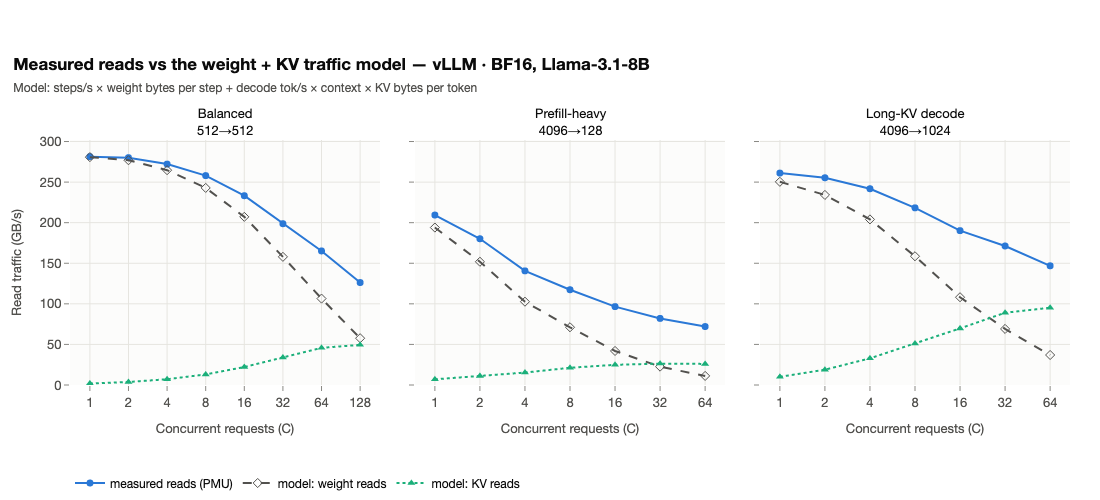

In [5]:
vllm_id = registry.configurations_frame().query("backend == 'vllm' and precision == 'bf16'")["configuration_id"].iloc[0]
fig = plots.traffic_components(primary[primary["workload"].isin(["balanced", "kvdecode", "prefill"])], vllm_id,
                               title=f"Measured reads vs the weight + KV traffic model — {registry.configuration_label(vllm_id)}, "
                                     f"{registry.model_label(MODEL)}",
                               subtitle="Model: steps/s × weight bytes per step + decode tok/s × context × KV bytes per token")
fig.show()
export_figure(fig, "memory_traffic_components", source=NOTEBOOK,
              caption="vLLM measured read traffic vs modelled weight and KV read terms across concurrency (8B).")

In [6]:
dec = pts[pts["decode_dominated"]]
fit = dec.groupby("backend")["measured_over_model_read"].describe()[["count", "50%", "min", "max"]]
display(table(fit.reset_index().rename(columns={"backend": "Backend", "count": "Points", "50%": "Median measured ÷ model",
                                                "min": "Min", "max": "Max"}),
              {"Points": "{:.0f}", "Median measured ÷ model": "{:.2f}", "Min": "{:.2f}", "Max": "{:.2f}"},
              caption="Decode-dominated points (ISL ≤ OSL): how well the weight + KV model explains measured reads"))
kv = primary[(primary["configuration_id"] == vllm_id) & (primary["workload"] == "kvdecode")].set_index("concurrency")
show(f"Long-KV decode (4096→1024), {registry.configuration_label(vllm_id)}: modelled KV share of the read traffic grows from "
     f"{pct(kv['model_kv_share'].iloc[0], signed=False)} at C=1 to {pct(kv['model_kv_share'].iloc[-1], signed=False)} at C={kv.index[-1]}; "
     f"modelled KV reads {num(kv['model_kv_read_gbs'].iloc[0])} → {num(kv['model_kv_read_gbs'].iloc[-1])} GB/s, weight reads "
     f"{num(kv['model_weight_read_gbs'].iloc[0])} → {num(kv['model_weight_read_gbs'].iloc[-1])} GB/s; measured total "
     f"{num(kv['mem_total_gbs_mean'].iloc[0])} → {num(kv['mem_total_gbs_mean'].iloc[-1])} GB/s while throughput grows "
     f"{x(kv['speedup_vs_c1'].iloc[-1])}.")

Backend,Points,Median measured ÷ model,Min,Max
llama_cpp,56,1.12,0.96,1.52
vllm,34,1.00,0.96,1.18


Long-KV decode (4096→1024), vLLM · BF16: modelled KV share of the read traffic grows from 4% at C=1 to 72% at C=64; modelled KV reads 10 → 95 GB/s, weight reads 250 → 37 GB/s; measured total 263 → 154 GB/s while throughput grows 7.6×.

**Interpretation.**
- Every forward step reads all weights once, whatever the batch. At C = 1, decode is a weight-streaming loop —
  the most bandwidth-bound regime of this workload. Batching amortizes that read over more tokens, while the
  arithmetic per step grows with the batch; steps get slower, fewer weight reads happen per second, and traffic
  falls.
- The model explains the measured reads closely wherever decode dominates (median ratio ≈ 1), so the falling
  traffic is an arithmetic consequence of batching, not a measurement artifact. The model is a lower bound: the
  excess grows with batch (activations, attention intermediates) and is largest where prefill dominates.
- KV reads are the term that *does* grow with concurrency (each sequence reads its own cache). In long-KV decode
  they become the dominant part of the traffic at high C, yet the total still falls because each step becomes
  slower than the memory system.

## 3. Which backend keeps the memory system busier?

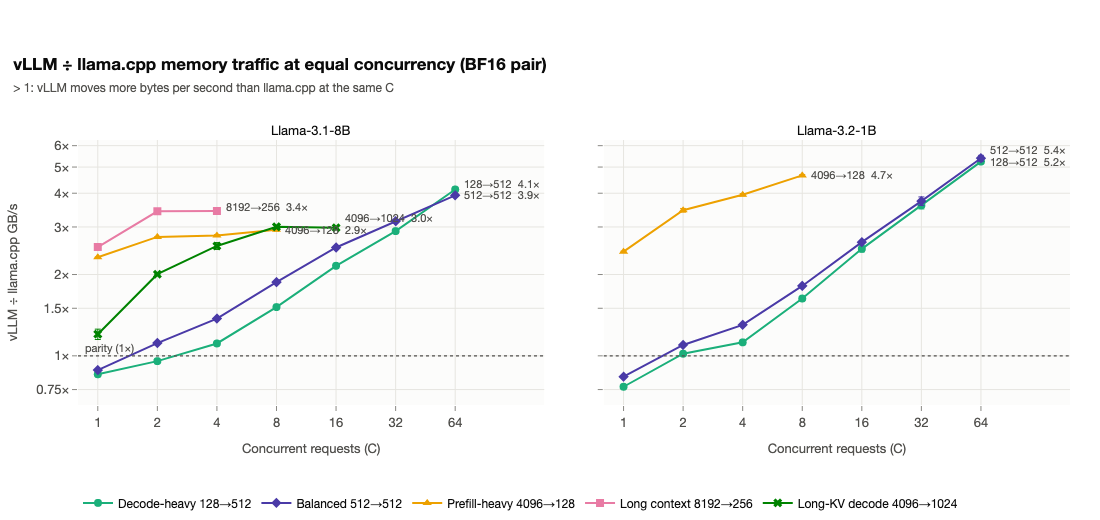

At C = 1 the traffic ratio is 0.77×–2.53×; from C = 8 upward it is 1.5×–5.4×.

In [7]:
traffic_ratio = comparisons.backend_ratio(pts, "mem_total_gbs_mean", precision="bf16")
fig = plots.ratio_vs_concurrency(traffic_ratio, title="vLLM ÷ llama.cpp memory traffic at equal concurrency (BF16 pair)",
                                 subtitle="> 1: vLLM moves more bytes per second than llama.cpp at the same C",
                                 y_title="vLLM ÷ llama.cpp GB/s")
fig.show()
t8 = traffic_ratio[traffic_ratio["concurrency"] >= 8]
t1 = traffic_ratio[traffic_ratio["concurrency"] == 1]
show(f"At C = 1 the traffic ratio is {rng(t1['ratio'], x, nd=2)}; from C = 8 upward it is {rng(t8['ratio'], x)}.")

**Interpretation.** With a single request on the short-prompt shapes llama.cpp streams the weights faster and moves
more traffic than vLLM (it also has the lower TPOT); on the long-prompt shapes vLLM's faster prefill already moves
more at C = 1. From moderate concurrency on, vLLM moves several times more bytes per second
than llama.cpp at the same C, because it completes many more forward steps per second and each step reads the
weights once plus the growing KV cache. vLLM therefore keeps the memory system busier *while* doing much more
useful work, over the whole concurrency range the thesis wants to explore.

## 4. Claims checked against the data

In [8]:
vt = trend[trend["configuration_id"] == vllm_id]
claims = [
    Claim("For every configuration and workload, memory traffic at the highest C is below that at C = 1",
          bool(trend["traffic_falls_with_c"].all()), f"{int(trend['traffic_falls_with_c'].sum())}/{len(trend)} curves"),
    Claim("No measured point exceeds 70% of the sustainable bandwidth",
          bool(trend["max_bw_util"].max() < 0.70), f"max {pct(trend['max_bw_util'].max(), signed=False)}"),
    Claim("The weight + KV model explains vLLM's decode-dominated reads within ±20% (median)",
          bool(abs(fit.loc['vllm', '50%'] - 1) < 0.2), f"median {fit.loc['vllm', '50%']:.2f}"),
    Claim("From C = 8 upward vLLM moves more memory traffic than llama.cpp at the same C (BF16)",
          bool((t8["ratio"] > 1).all()), rng(t8["ratio"], x)),
    Claim("In long-KV decode the modelled KV share of vLLM's reads exceeds 50% at its highest C",
          bool(kv["model_kv_share"].iloc[-1] > 0.5), pct(kv["model_kv_share"].iloc[-1], signed=False)),
]
display(claims_table(claims))

Holds,Statement,Evidence (computed)
✓,"For every configuration and workload, memory traffic at the highest C is below that at C = 1",23/23 curves
✓,No measured point exceeds 70% of the sustainable bandwidth,max 65%
✓,The weight + KV model explains vLLM's decode-dominated reads within ±20% (median),median 1.00
✓,From C = 8 upward vLLM moves more memory traffic than llama.cpp at the same C (BF16),1.5×–5.4×
✓,In long-KV decode the modelled KV share of vLLM's reads exceeds 50% at its highest C,72%


## Conclusions

- **Measured:** for both backends and every workload, total memory traffic is highest at C = 1 and falls as
  concurrency rises; no configuration approaches the STREAM-sustainable bandwidth. vLLM sustains several times more
  traffic than llama.cpp at equal C from moderate concurrency upward, while also delivering several times more
  throughput.
- **Interpretation:** concurrency shifts serving from weight streaming to batched compute; KV reads grow with C but
  do not outweigh the amortized weight reads in the measured shapes.
- **Implication for the thesis:** "more concurrency ⇒ more HBM pressure" is **not** supported as a general rule.
  HBM pressure under serving lives in two regimes: low-batch decode (weight streaming) and decode over long, growing
  KV caches at high concurrency, where KV traffic scales with C × context. The HBM experiments should target those
  regimes explicitly, with vLLM as the platform that can reach high C in them; short-context, high-C cells serve as
  a compute-bound control.

## Limitations

- Cache mode: HBM-cache hits and DDR traffic are not separable with core counters; flat-mode placement experiments
  or uncore access (lower `perf_event_paranoid` on one node) are needed for an HBM/DDR split.
- The traffic model ignores activations, attention intermediates and prefill attention, so it is a lower bound.
- Longer contexts or larger KV footprints (beyond 4096→1024) were not measured; they are the natural next regime.